# Classification

Classification is probably the best know use of Bayesian methods due to their application in spam filters. 

## Penguin Data

In [42]:
import pandas as pd

df = pd.read_csv('/Users/colelacroix/math/01_Think_Bayes_(Downey)/data/penguins_raw.csv').dropna(subset=['Body Mass (g)'])
df.shape

(342, 17)

In [43]:
def shorten(species):
    return species.split()[0]

df['Species2'] = df['Species'].apply(shorten)

In [44]:
import matplotlib.pyplot as plt

def make_cdf_map(df, colname, by = 'Species2'):
    """ make a CDF for each species """
    cdf_map = {}
    grouped = df.groupby(by)[colname]
    for species, group in grouped:
        cdf_map[species] = Cdf.from_seq(group, name = species)
    return cdf_map

In [45]:
from empiricaldist import Cdf
from utils import decorate

def plot_cdfs(df, colname, by='Species2'):
    """Make a CDF for each species.
    
    df: DataFrame
    colname: string column name
    by: string column name

    returns: dictionary from species name to Cdf
    """
    cdf_map = make_cdf_map(df, colname, by)
    
    for species, cdf in cdf_map.items():
        cdf.plot(label=species, marker='')
    
    decorate(xlabel=colname,
             ylabel='CDF')

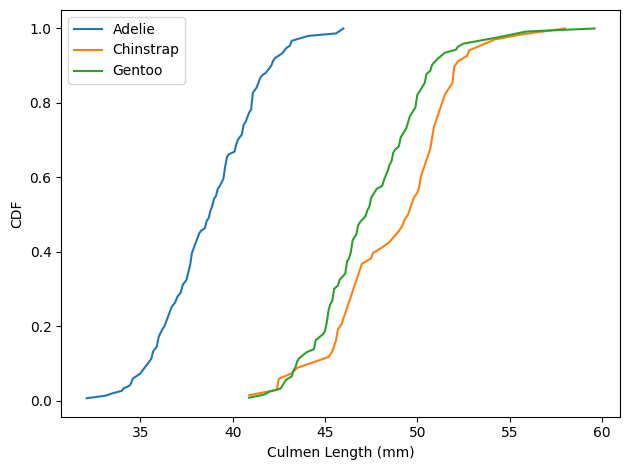

In [46]:
colname = 'Culmen Length (mm)'
plot_cdfs(df, colname)

Looks like we can use culmen length (ridge on beak) to identify Adelie penguins but the others are too similar. 

Let's look at flipper length:

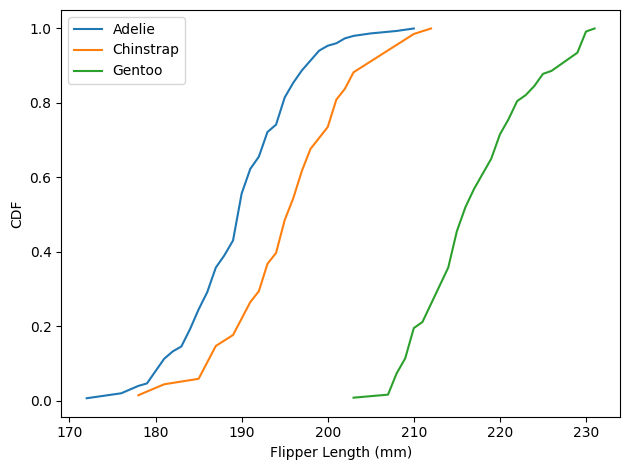

In [47]:
colname = 'Flipper Length (mm)'
plot_cdfs(df, colname)

Looks like we can use flipper length to distinguish Gentoo penguins. 

## Normal Models

We will use this data to classify penguins. We'll use the usual Bayesian steps:

1. Define a prior distribution with three possible species and prior probabilities for each.
2. Compute the likelihood of the data for each hypothetical species.
3. Compute the posterior probability for each hypothesis. 

In [48]:
from scipy.stats import norm

def make_norm_map(df, colname, by='Species2'):
    """ Make a map from species to norm object"""
    norm_map = {}
    grouped = df.groupby(by)[colname]
    for species, group in grouped:
        mean = group.mean()
        std = group.std()
        norm_map[species] = norm(mean, std)
    return norm_map

In [49]:
flipper_map = make_norm_map(df, 'Flipper Length (mm)')
flipper_map.keys()

dict_keys(['Adelie', 'Chinstrap', 'Gentoo'])

So, suppose we find a penguin with a 193 mm flipper. What is the probability of that measurement against each hypothesis?

The norm object gives us a pdf. 

In [50]:
data = 193
flipper_map['Adelie'].pdf(data)

np.float64(0.054732511875530694)

The result is a probability density (not a probability). But, it's proportional to the likelihood of the data, so we can use it to update the prior. 

In [51]:
# compute the likelihood of the data in each distribution

hypos = flipper_map.keys()
likelihood = [flipper_map[hypo].pdf(data) for hypo in hypos]
likelihood

[np.float64(0.054732511875530694),
 np.float64(0.05172135615888162),
 np.float64(5.8660453661990634e-05)]

## Update

In [52]:
from empiricaldist import Pmf

prior = Pmf(1/3, hypos)
prior

,probs
Adelie,0.333333
Chinstrap,0.333333
Gentoo,0.333333


In [53]:
posterior = prior * likelihood
posterior.normalize()
posterior

,probs
Adelie,0.513860
Chinstrap,0.485589
Gentoo,0.000551


Looks like it could be an Adelie or Chinstrap but not likely a Gentoo (assuming their odds of observation were equal). Here is a function for that same operation:

In [54]:
def update_penguin(prior, data, norm_map):
    """ update hypothetical species """
    hypos = prior.qs
    likelihood = [norm_map[hypo].pdf(data) for hypo in hypos]
    posterior = prior * likelihood
    posterior.normalize()
    return posterior

In [55]:
posterior1 = update_penguin(prior, 193, flipper_map)
posterior1

,probs
Adelie,0.513860
Chinstrap,0.485589
Gentoo,0.000551


As we saw before, flipper length can only get us so far. Let's now use culmen length to make additional distictions between the species. 

In [56]:
culmen_map = make_norm_map(df, 'Culmen Length (mm)')

# suppose penguin with 48 mm culmen

posterior2 = update_penguin(prior, 48, culmen_map)
posterior2

,probs
Adelie,0.001557
Chinstrap,0.474658
Gentoo,0.523785


## Naive Bayesian Classification

In [57]:
def update_naive(prior, data_seq, norm_maps):
    """ Naive Bayesian Classifier
    prior: pmf
    data_seq: sequence of measurements
    norm_maps: sequence of maps for species distributions

    returns: pmf representing posterior distribution """
    posterior = prior.copy()
    for data, norm_map in zip(data_seq, norm_maps):
        posterior = update_penguin(posterior, data, norm_map)
    return posterior

This function performs a series of updates using one variable at a time and returns a posterior pmf. Let's test it:

In [58]:
colnames = ['Flipper Length (mm)', 'Culmen Length (mm)']
norm_maps = [flipper_map, culmen_map]

Now suppose we find a penguin with flipper length 193 mm and culmen length 48. Here is the update:

In [59]:
data_seq = 193, 48
posterior = update_naive(prior, data_seq, norm_maps)
posterior

,probs
Adelie,0.003455
Chinstrap,0.995299
Gentoo,0.001246


It is almost certainly a Chinstrap

In [60]:
posterior.max_prob()

'Chinstrap'

We can loop through the dataset and classify each penguin with these two features:

In [61]:
import numpy as np
df['Classification'] = pd.Series(dtype='object')
# df['Classification'] = np.nan

for i, row in df.iterrows():
    data_seq = row[colnames]
    posterior = update_naive(prior, data_seq, norm_maps)
    df.loc[i, 'Classification'] = posterior.max_prob()

In [62]:
# see how many it got right

valid = df['Classification'].notna()
valid.sum()

np.int64(342)

In [63]:
same = df['Species2'] == df['Classification']
same.sum()

np.int64(324)

So, there are 344 data entries, 342 with all their data. Using the classifier, 324 were classified correctly, almost 95%. 

In [64]:
same.sum() / valid.sum()

np.float64(0.9473684210526315)

In [65]:
# accuracy function

def accuracy(df):
    """ compute the accuracy of classification """
    valid = df['Classification'].notna()
    same = df['Species2'] == df['Classification']
    return same.sum() / valid.sum()

This classifier is called naive because it ignores correlations between the features. Let's compare to one that does:

## Joint Distributions

In [68]:
def scatterplot(df, var1, var2):
    """ make a scatter plot """
    grouped = df.groupby('Species2')
    for species, group in grouped:
        plt.plot(group[var1], group[var2], 
                 label = species, lw = 0, marker = 'o', alpha = 0.3)
        decorate(xlabel = var1, ylabel = var2)

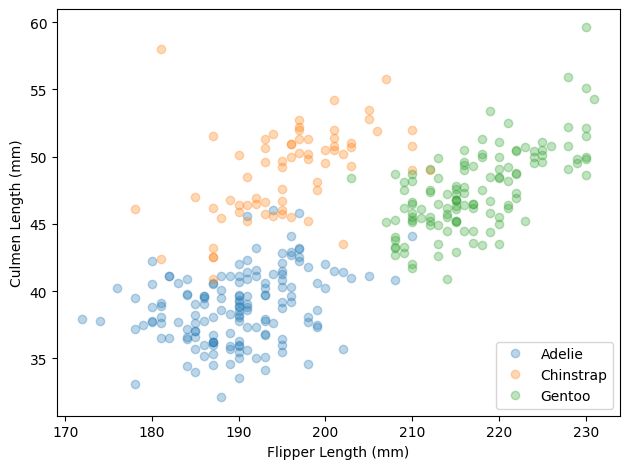

In [70]:
var1 = 'Flipper Length (mm)'
var2 = 'Culmen Length (mm)'
scatterplot(df, var1, var2)

If we were to draw shapes to capture the distributions of these points, we would see ovals along the diagonal. Because they are along the diagnal, it means they have a positive correlation. 

Ignoring these correlations would be to assume independence. 

In [77]:
def make_pmf_norm(dist, sigmas = 3, n = 101):
    """ make a pmf approximation to a normal distribution"""
    mean, std = dist.mean(), dist.std()
    low = mean - sigmas * std
    high = mean + sigmas * std
    qs = np.linspace(low, high, n)
    ps = dist.pdf(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf

In [78]:
from utils import make_joint

joint_map = {}
for species in hypos:
    pmf1 = make_pmf_norm(flipper_map[species])
    pmf2 = make_pmf_norm(culmen_map[species])
    joint_map[species] = make_joint(pmf1, pmf2)

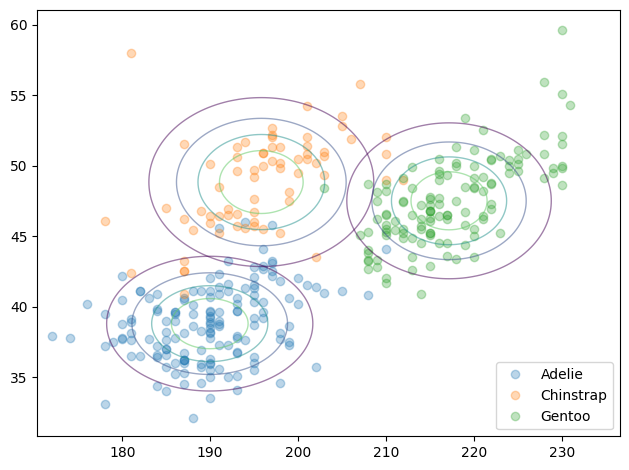

In [79]:
from utils import plot_contour

scatterplot(df, var1, var2)
for species in hypos:
    plot_contour(joint_map[species], alpha=0.5)

The contours of the joint normal distributions form ellipses. Because the features are uncorrelated, the ellipses are aligned with the axes but do not align well with the data. 

We can make a better model of the data and use it to compute better likelihoods with a multivariate normal distribution. 

## Multivariate Normal Distribution

A multivariate normal distribution is characterized by the means of the features and the covariace matrix which contains variances which quantify the spread of the features and the covariances which quantify the relationships among them. 

We can use data to estimate the means and covariance matrix for the penguin population. 

In [80]:
features = df[[var1, var2]]

In [81]:
mean = features.mean()
mean

Flipper Length (mm)    200.915205
Culmen Length (mm)      43.921930
dtype: float64

In [82]:
cov = features.cov()
cov

,Flipper Length (mm),Culmen Length (mm)
Flipper Length (mm),197.731792,50.375765
Culmen Length (mm),50.375765,29.807054


This gives us a data frame. The elements on the diagonal are variances. The elements off the diagonal are covariances. 

In [83]:
from scipy.stats import multivariate_normal

multinorm = multivariate_normal(mean, cov)

In [84]:
def make_multinorm_map(df, colnames):
    """Make a map from each species to a multivariate normal."""
    multinorm_map = {}
    grouped = df.groupby('Species2')
    for species, group in grouped:
        features = group[colnames]
        mean = features.mean()
        cov = features.cov()
        multinorm_map[species] = multivariate_normal(mean, cov)
    return multinorm_map

In [85]:
multinorn_map = make_multinorm_map(df, [var1, var2])

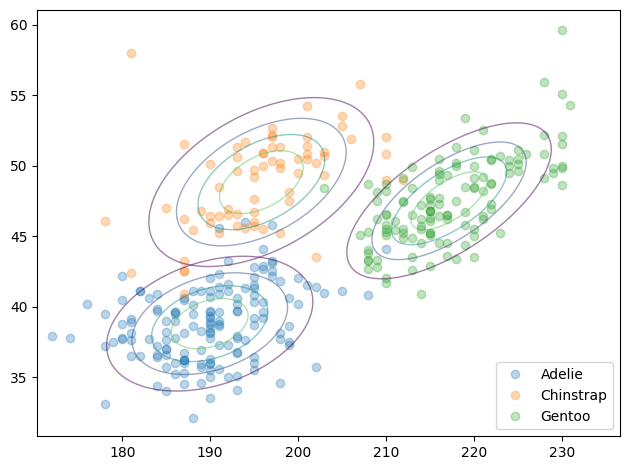

In [90]:
scatterplot(df, var1, var2)

for species in hypos:
    norm1 = flipper_map[species]
    norm2 = culmen_map[species]
    multinorm = multinorm_map[species]
    joint = make_joint(norm1, norm2, multinorm)
    plot_contour(joint, alpha=0.5)

## Less Naive Classifier

In the previous section, we used upate_penguin to update a prior Pmf based on observations and norm objects that model the distributions of obervations under each hypothesis. 

Last time we used the function, the values in norm_map were norm objects. But, we can now use our multivariate_normal objects. 

In [91]:
data = 193, 48
update_penguin(prior, data, multinorm_map)

,probs
Adelie,0.002740
Chinstrap,0.997257
Gentoo,0.000003


Now let's see if the classifier does any better than the naive Bayesian classifier. 

In [93]:
df['Classification'] = pd.Series(dtype='object')

for i, row in df.iterrows():
    data = row[colnames]
    posterior = update_penguin(prior, data, multinorm_map)
    df.loc[i, 'Classification'] = posterior.idxmax()

In [94]:
accuracy(df)

np.float64(0.9532163742690059)

It's 